<a href="https://colab.research.google.com/github/natthaphonmint/wave_prediction_project/blob/main/CNN-1D%20Model/CNN_1D_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import urllib.request
import pickle
import os

# 1. ลิงก์ Raw ที่ชี้ไปยังไฟล์ .pkl บน GitHub ของคุณโดยตรง
url_pkl = 'https://raw.githubusercontent.com/natthaphonmint/wave_prediction_project/main/Time_Series_Split/data_split_patong.pkl'
file_name = 'data_split_patong.pkl'

# 2. ดาวน์โหลดไฟล์จาก GitHub มาไว้ในเครื่อง Colab
print("กำลังดาวน์โหลดไฟล์จาก GitHub...")
urllib.request.urlretrieve(url_pkl, file_name)
print("ดาวน์โหลดสำเร็จ!")

# 3. ใช้ pickle เปิดอ่านไฟล์ที่เพิ่งดาวน์โหลดมา
print("กำลังโหลดข้อมูลเข้าตัวแปร...")
with open(file_name, 'rb') as f:
    data_split = pickle.load(f)

# 4. แตก variables ออกมาใช้งาน
X = data_split['X']
y = data_split['y']
X_test = data_split['X_test']
y_test = data_split['y_test']
split_indices = data_split['split_indices']
N_SPLITS = data_split['n_splits']
TARGET = data_split['target_column']
tscv = data_split['tscv']

print("-" * 30)
print("✅ โหลดข้อมูลเข้าตัวแปรสำเร็จพร้อมใช้งาน!")
print(f"X shape      : {X.shape}")
print(f"y shape      : {y.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_test shape : {y_test.shape}")

กำลังดาวน์โหลดไฟล์จาก GitHub...
ดาวน์โหลดสำเร็จ!
กำลังโหลดข้อมูลเข้าตัวแปร...
------------------------------
✅ โหลดข้อมูลเข้าตัวแปรสำเร็จพร้อมใช้งาน!
X shape      : (70128, 10)
y shape      : (70128,)
X_test shape : (1416, 10)
y_test shape : (1416,)


In [7]:
import pickle
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# ─────────────────────────────────────────
# 1. โหลดข้อมูลจาก data_split.pkl
# ─────────────────────────────────────────
load_path = file_name # แก้ไข: โหลดจากไฟล์ที่ดาวน์โหลดมาในไดเรกทอรีปัจจุบัน

with open(load_path, 'rb') as f:
    data_split = pickle.load(f)

X             = data_split['X']
y             = data_split['y']
X_test        = data_split['X_test']   # ← เก็บไว้ ห้ามแตะจนพยากรณ์จริง
y_test        = data_split['y_test']   # ← เก็บไว้ ห้ามแตะจนพยากรณ์จริง
split_indices = data_split['split_indices']
N_SPLITS      = data_split['n_splits']
TARGET        = data_split['target_column']
tscv          = data_split['tscv']

# Remove 'day_of_year' column from X as requested by the user
X = X.drop(columns=['day_of_year'])

print("โหลดสำเร็จ!")
print(f"  X shape      : {X.shape}")
print(f"  y shape      : {y.shape}")
print(f"  X_test shape : {X_test.shape}")
print(f"  y_test shape : {y_test.shape}")
print(f"  N_SPLITS     : {N_SPLITS}")
print(f"  Keys         : {list(split_indices.keys())}")

# ─────────────────────────────────────────
# 2. StandardScaler แต่ละ fold
# ─────────────────────────────────────────
scaled_data_folds = {}

for fold_num in range(1, N_SPLITS + 1):
    train_index = split_indices[f'fold_{fold_num}_train']
    val_index   = split_indices[f'fold_{fold_num}_val']   # ✅ ใช้ _val ไม่ใช่ _test

    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    # Fit บน train เท่านั้น → transform val (ห้าม fit_transform บน val)
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )
    X_val_scaled = pd.DataFrame(
        scaler.transform(X_val),
        columns=X_val.columns,
        index=X_val.index
    )

    scaled_data_folds[f'fold_{fold_num}'] = {
        'X_train_scaled': X_train_scaled,
        'y_train':        y_train,
        'X_val_scaled':   X_val_scaled,
        'y_val':          y_val,
        'scaler':         scaler  # ✅ เก็บไว้ใช้ transform X_test ตอนพยากรณ์
    }

    print(f"\n--- Fold {fold_num} ---")
    print(f"  Train: {X_train_scaled.shape}  {X_train.index.min().date()} → {X_train.index.max().date()}")
    print(f"  Val  : {X_val_scaled.shape}  {X_val.index.min().date()} → {X_val.index.max().date()}")

print("\nScale ข้อมูลทุก fold สำเร็จ!")
print("หมายเหตุ: X_test / y_test ยังไม่ถูก scale → จะ scale ตอนพยากรณ์จริงเท่านั้น")

โหลดสำเร็จ!
  X shape      : (70128, 9)
  y shape      : (70128,)
  X_test shape : (1416, 10)
  y_test shape : (1416,)
  N_SPLITS     : 5
  Keys         : ['fold_1_train', 'fold_1_val', 'fold_2_train', 'fold_2_val', 'fold_3_train', 'fold_3_val', 'fold_4_train', 'fold_4_val', 'fold_5_train', 'fold_5_val']

--- Fold 1 ---
  Train: (11688, 9)  2018-01-01 → 2019-05-02
  Val  : (11688, 9)  2019-05-03 → 2020-08-31

--- Fold 2 ---
  Train: (23376, 9)  2018-01-01 → 2020-08-31
  Val  : (11688, 9)  2020-09-01 → 2021-12-31

--- Fold 3 ---
  Train: (35064, 9)  2018-01-01 → 2021-12-31
  Val  : (11688, 9)  2022-01-01 → 2023-05-02

--- Fold 4 ---
  Train: (46752, 9)  2018-01-01 → 2023-05-02
  Val  : (11688, 9)  2023-05-03 → 2024-08-31

--- Fold 5 ---
  Train: (58440, 9)  2018-01-01 → 2024-08-31
  Val  : (11688, 9)  2024-09-01 → 2025-12-31

Scale ข้อมูลทุก fold สำเร็จ!
หมายเหตุ: X_test / y_test ยังไม่ถูก scale → จะ scale ตอนพยากรณ์จริงเท่านั้น


In [8]:
import numpy as np # Ensure numpy is imported if not already
import pandas as pd # Import pandas for DataFrame/Series type checking

def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    # Convert DataFrame/Series to numpy arrays for simpler slicing
    X_values = X.values if isinstance(X, (pd.DataFrame, pd.Series)) else X
    y_values = y.values if isinstance(y, (pd.DataFrame, pd.Series)) else y

    for i in range(len(X_values) - time_steps):
        v = X_values[i:(i + time_steps)]
        Xs.append(v)
        ys.append(y_values[i + time_steps])
    return np.array(Xs), np.array(ys)

# Define the number of time steps (look-back period)
TIME_STEPS = 24 # ใช้ข้อมูลย้อนหลัง 24 ชั่วโมง

# Dictionary to store the created sequences for each fold
sequences_folds = {}

# Loop through each fold in scaled_data_folds to create sequences
for fold_name, fold_data in scaled_data_folds.items(): # Corrected variable name from scaled_data_folds_hua_sai to scaled_data_folds
    X_train_scaled = fold_data['X_train_scaled']
    y_train = fold_data['y_train'] # Use the unscaled y_train
    X_val_scaled = fold_data['X_val_scaled'] # Use X_val_scaled for validation sequences
    y_val = fold_data['y_val']   # Use y_val for validation sequences

    # Create sequences for training data
    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, TIME_STEPS)

    # Create sequences for validation data (not test data here)
    X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val, TIME_STEPS)

    # Store the sequences for the current fold
    sequences_folds[fold_name] = {
        'X_train_seq': X_train_seq,
        'y_train_seq': y_train_seq,
        'X_val_seq': X_val_seq,
        'y_val_seq': y_val_seq
    }

    print(f"\n--- {fold_name} Sequences Shapes ---")
    print("X_train_seq shape:", X_train_seq.shape)
    print("y_train_seq shape:", y_train_seq.shape)
    print("X_val_seq shape:", X_val_seq.shape)
    print("y_val_seq shape:", y_val_seq.shape)

print("\nSequence creation for all folds completed. Sequences stored in 'sequences_folds' dictionary.")


--- fold_1 Sequences Shapes ---
X_train_seq shape: (11664, 24, 9)
y_train_seq shape: (11664,)
X_val_seq shape: (11664, 24, 9)
y_val_seq shape: (11664,)

--- fold_2 Sequences Shapes ---
X_train_seq shape: (23352, 24, 9)
y_train_seq shape: (23352,)
X_val_seq shape: (11664, 24, 9)
y_val_seq shape: (11664,)

--- fold_3 Sequences Shapes ---
X_train_seq shape: (35040, 24, 9)
y_train_seq shape: (35040,)
X_val_seq shape: (11664, 24, 9)
y_val_seq shape: (11664,)

--- fold_4 Sequences Shapes ---
X_train_seq shape: (46728, 24, 9)
y_train_seq shape: (46728,)
X_val_seq shape: (11664, 24, 9)
y_val_seq shape: (11664,)

--- fold_5 Sequences Shapes ---
X_train_seq shape: (58416, 24, 9)
y_train_seq shape: (58416,)
X_val_seq shape: (11664, 24, 9)
y_val_seq shape: (11664,)

Sequence creation for all folds completed. Sequences stored in 'sequences_folds' dictionary.



--- Training and Evaluating for fold_1 ---


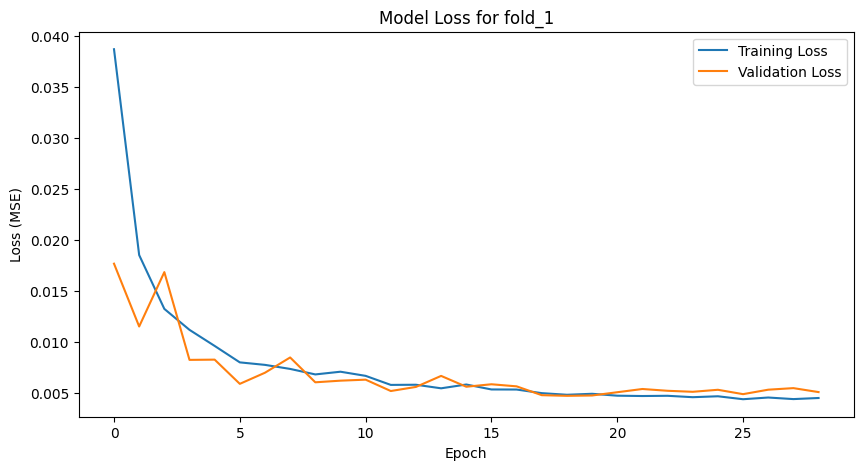

365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
RMSE: 0.0685
MAE: 0.0525
NRMSE: 0.0317
MAPE: 7.8326
R2: 0.9614

--- Training and Evaluating for fold_2 ---


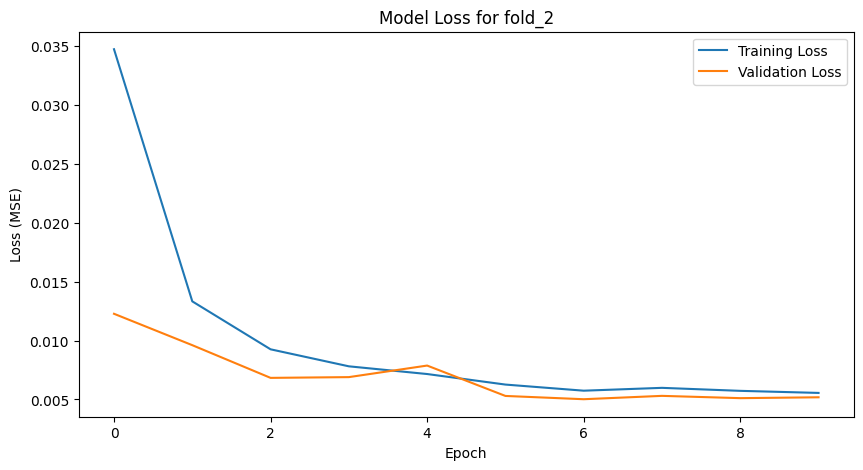

365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
RMSE: 0.1108
MAE: 0.0768
NRMSE: 0.0488
MAPE: 8.6943
R2: 0.9099

--- Training and Evaluating for fold_3 ---


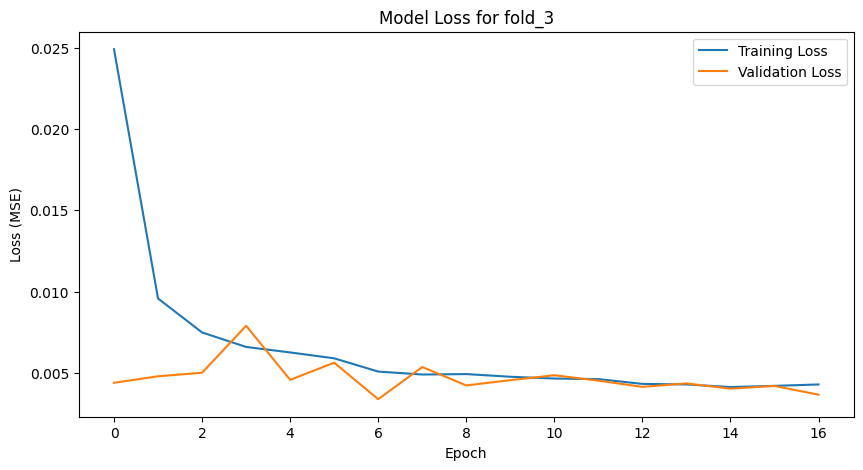

365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
RMSE: 0.0580
MAE: 0.0466
NRMSE: 0.0274
MAPE: 7.7217
R2: 0.9719

--- Training and Evaluating for fold_4 ---


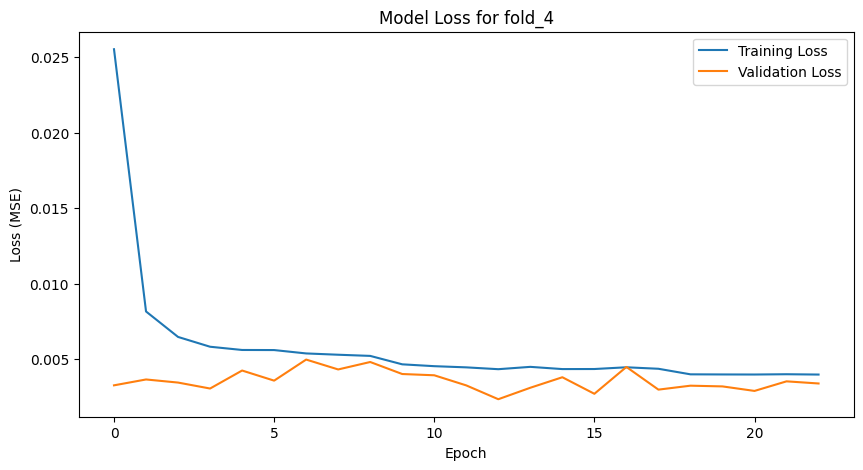

365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
RMSE: 0.0484
MAE: 0.0377
NRMSE: 0.0196
MAPE: 6.5227
R2: 0.9814

--- Training and Evaluating for fold_5 ---


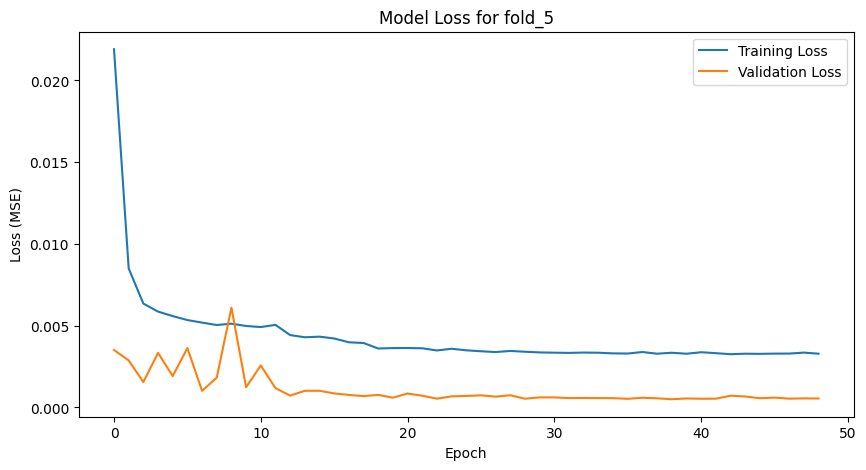

365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
RMSE: 0.0225
MAE: 0.0152
NRMSE: 0.0094
MAPE: 1.8459
R2: 0.9959

--- Overall Cross-Validation Results ---
Average RMSE across folds: 0.0616 (Std: 0.0289)
Average MAE across folds: 0.0458 (Std: 0.0200)
Average NRMSE across folds: 0.0274 (Std: 0.0131)
Average MAPE across folds: 6.5235 (Std: 2.4389)
Average R2 across folds: 0.9641 (Std: 0.0294)

────────────────────────────────────────────────────────────
  Fold             RMSE      MAE    NRMSE     MAPE       R2
  ────────────────────────────────────────────────────────
  fold_1         0.0685   0.0525   0.0317   7.8326   0.9614
  fold_2         0.1108   0.0768   0.0488   8.6943   0.9099
  fold_3         0.0580   0.0466   0.0274   7.7217   0.9719
  fold_4         0.0484   0.0377   0.0196   6.5227   0.9814
  fold_5         0.0225   0.0152   0.0094   1.8459   0.9959
  ────────────────────────────────────────────────────────
  Average        0.0616   0.0458   0.0274   6.5235   0.9641
  Std           

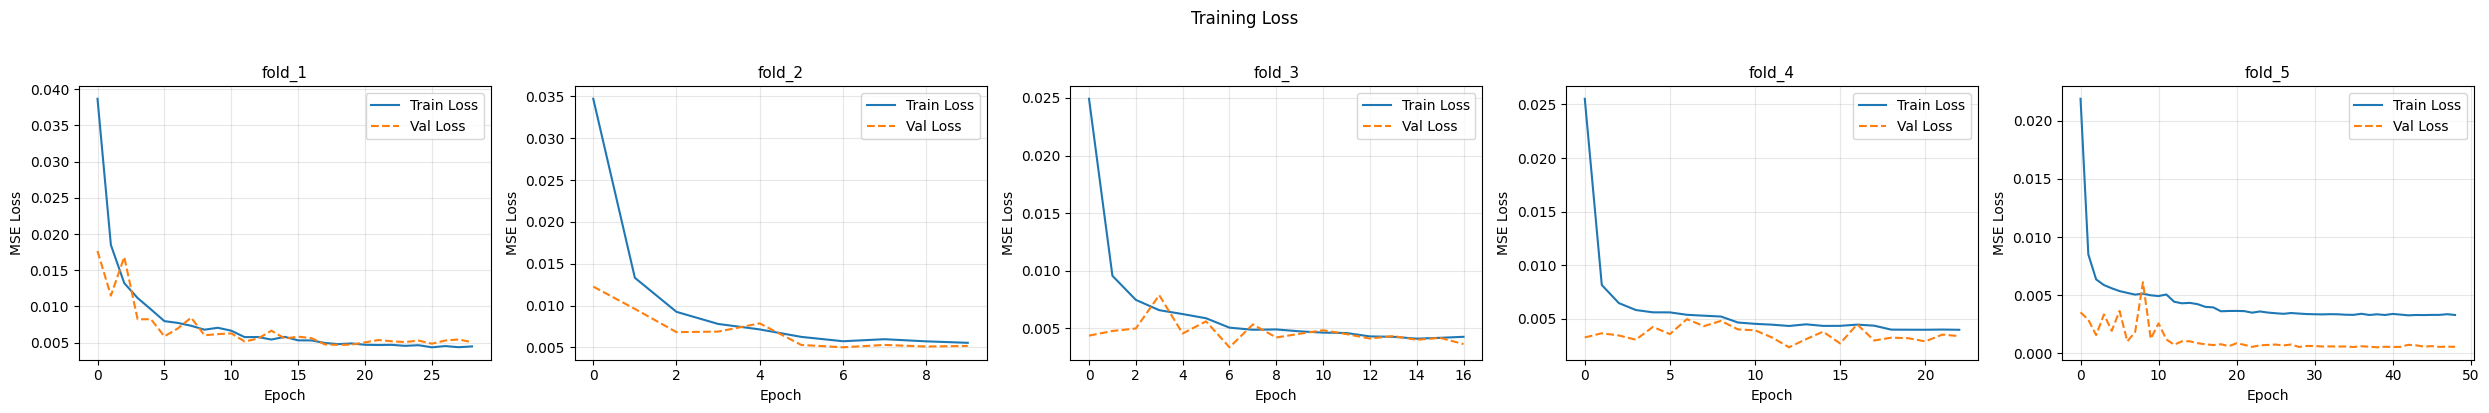


เตรียมข้อมูล Test และพยากรณ์
  X_test_scaled shape: (1416, 9)
  X_test_seq shape   : (1416, 24, 9)
  y_test_seq shape   : (1416,)
กำลังพยากรณ์ค่าบน X_test_seq...
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
✅ พยากรณ์เสร็จสิ้น

  Test RMSE  : 0.0291
  Test MAE   : 0.0227
  Test NRMSE : 0.0299
  Test MAPE  : 4.1723
  Test R2    : 0.9768


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Input, BatchNormalization, Dropout
from tensorflow.keras.regularizers import l1
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # Import r2_score
import numpy as np
import matplotlib.pyplot as plt
import random # Import the random module
import os


# Set random seeds for reproducibility
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(42)

# Define model building function to create a fresh model for each fold
def build_cnn_model(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu'))  # เพิ่มอีกชั้น
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))
    model.add(Flatten())
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1))  # ลบ regularizer ออก
    model.compile(optimizer='adam', loss='mse')
    return model

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001)

# Lists to store metrics for each fold
all_rmse = []
all_mae = []
all_nrmse = []
all_mape = []
all_r2 = [] # Add list for R2 scores

# Dictionaries to store fold-wise metrics and histories for plotting/summary
fold_metrics = {}
fold_histories = {}
last_model = None # Initialize last_model

# Loop through each fold to train and evaluate the model
for fold_name, fold_data in sequences_folds.items():
    print(f"\n--- Training and Evaluating for {fold_name} ---")
    X_train_seq = fold_data['X_train_seq']
    y_train_seq = fold_data['y_train_seq']
    # Corrected: Use X_val_seq and y_val_seq for evaluation within the fold
    X_val_seq = fold_data['X_val_seq']
    y_val_seq = fold_data['y_val_seq']

    # Build a new model for each fold to ensure fresh weights
    model = build_cnn_model((X_train_seq.shape[1], X_train_seq.shape[2]))

    # Train the model
    history = model.fit(X_train_seq, y_train_seq, epochs=100, batch_size=16,
                        validation_data=(X_val_seq, y_val_seq), verbose=0, callbacks=[early_stopping, reduce_lr])

    # Store history for plotting
    fold_histories[fold_name] = history

    # Plot training and validation loss for the current fold
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Model Loss for {fold_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.show()

    # Make predictions on the validation set for this fold
    y_pred_val = model.predict(X_val_seq)

    # Calculate metrics for the validation set
    rmse = np.sqrt(mean_squared_error(y_val_seq, y_pred_val))
    mae = mean_absolute_error(y_val_seq, y_pred_val)
    r2 = r2_score(y_val_seq, y_pred_val) # Calculate R2

    range_y_val = y_val_seq.max() - y_val_seq.min()
    nrmse = rmse / range_y_val if range_y_val != 0 else np.nan

    epsilon = 1e-10
    mape = np.mean(np.abs((y_val_seq - y_pred_val.flatten()) / (y_val_seq + epsilon))) * 100

    print(f'RMSE: {rmse:.4f}')
    print(f'MAE: {mae:.4f}')
    print(f'NRMSE: {nrmse:.4f}')
    print(f'MAPE: {mape:.4f}')
    print(f'R2: {r2:.4f}') # Print R2

    all_rmse.append(rmse)
    all_mae.append(mae)
    all_nrmse.append(nrmse)
    all_mape.append(mape)
    all_r2.append(r2) # Append R2

    # Store metrics for this fold
    fold_metrics[fold_name] = {'rmse': rmse, 'mae': mae, 'nrmse': nrmse, 'mape': mape, 'r2': r2} # Add R2 to dict

    # Keep track of the model from the last fold
    last_model = model

print("\n--- Overall Cross-Validation Results ---")
print(f"Average RMSE across folds: {np.mean(all_rmse):.4f} (Std: {np.std(all_rmse):.4f})")
print(f"Average MAE across folds: {np.mean(all_mae):.4f} (Std: {np.std(all_mae):.4f})")
print(f"Average NRMSE across folds: {np.mean(all_nrmse):.4f} (Std: {np.std(all_nrmse):.4f})")
print(f"Average MAPE across folds: {np.mean(all_mape):.4f} (Std: {np.std(all_mape):.4f})")
print(f"Average R2 across folds: {np.mean(all_r2):.4f} (Std: {np.std(all_r2):.4f})") # Print Average R2


# ─────────────────────────────────────────
# ตาราง + กราฟ
# ─────────────────────────────────────────
print(f"\n{'─'*60}")
print(f"  {'Fold':<12} {'RMSE':>8} {'MAE':>8} {'NRMSE':>8} {'MAPE':>8} {'R2':>8}") # Add R2 header
print(f"  {'─'*56}") # Adjust separator length
for fn, m in fold_metrics.items():
    print(f"  {fn:<12} {m['rmse']:>8.4f} {m['mae']:>8.4f} {m['nrmse']:>8.4f} {m['mape']:>8.4f} {m['r2']:>8.4f}") # Print R2 value
print(f"  {'─'*56}") # Adjust separator length
print(f"  {'Average':<12} {np.mean(all_rmse):>8.4f} {np.mean(all_mae):>8.4f} {np.mean(all_nrmse):>8.4f} {np.mean(all_mape):>8.4f} {np.mean(all_r2):>8.4f}") # Print Average R2
print(f"  {'Std':<12} {np.std(all_rmse):>8.4f} {np.std(all_mae):>8.4f} {np.std(all_nrmse):>8.4f} {np.std(all_mape):>8.4f} {np.std(all_r2):>8.4f}") # Print R2 Std

n_folds = len(fold_histories)
# Handle case where n_folds might be 0 or 1 to avoid matplotlib errors
if n_folds == 0:
    print("No fold histories to plot.")
elif n_folds == 1:
    fig, axes = plt.subplots(1, n_folds, figsize=(5 * n_folds, 4))
    axes = [axes]
    for ax, (fn, hist) in zip(axes, fold_histories.items()):
        ax.plot(hist.history['loss'],     label='Train Loss', linewidth=1.5)
        ax.plot(hist.history['val_loss'], label='Val Loss',   linewidth=1.5, linestyle='--')
        ax.set_title(fn, fontsize=11)
        ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.suptitle(f'Training Loss', fontsize=12, y=1.02) # Removed undefined 'config'
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(1, n_folds, figsize=(5 * n_folds, 4))
    for ax, (fn, hist) in zip(axes, fold_histories.items()):
        ax.plot(hist.history['loss'],     label='Train Loss', linewidth=1.5)
        ax.plot(hist.history['val_loss'], label='Val Loss',   linewidth=1.5, linestyle='--')
        ax.set_title(fn, fontsize=11)
        ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.suptitle(f'Training Loss', fontsize=12, y=1.02) # Removed undefined 'config'
    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────
# พยากรณ์ X_test ด้วย fold สุดท้าย
# ─────────────────────────────────────────
print("\n" + "=" * 50)
print("เตรียมข้อมูล Test และพยากรณ์")
print("=" * 50)

last_fold_name  = f'fold_{N_SPLITS}'
scaler_for_test = scaled_data_folds[last_fold_name]['scaler']
# Corrected: last_model is now assigned inside the loop
# model_for_test  = last_model  # ✅ ใช้โมเดลที่อยู่ใน memory
model_for_test = last_model

# Remove 'day_of_year' from X_test before scaling
X_test_processed = X_test.drop(columns=['day_of_year'])

X_test_scaled = pd.DataFrame(
    scaler_for_test.transform(X_test_processed),
    columns=X_test_processed.columns,
    index=X_test_processed.index
)
print(f"  X_test_scaled shape: {X_test_scaled.shape}")

X_context = pd.DataFrame(
    scaler_for_test.transform(X.iloc[-TIME_STEPS:]), # Changed 167 to TIME_STEPS for consistency
    columns=X.columns,
    index=X.iloc[-TIME_STEPS:].index
)

X_test_full = pd.concat([X_context, X_test_scaled])
y_context   = pd.concat([y.iloc[-TIME_STEPS:], y_test]) # Changed 167 to TIME_STEPS for consistency

X_test_seq, y_test_seq = create_sequences(X_test_full, y_context, TIME_STEPS)
print(f"  X_test_seq shape   : {X_test_seq.shape}")
print(f"  y_test_seq shape   : {y_test_seq.shape}")

# X_test_win = create_cnn_windows(X_test_seq) # This function is not defined and likely not needed for LSTM
# print(f"  X_test_win shape   : {X_test_win.shape}")

print("กำลังพยากรณ์ค่าบน X_test_seq...")
y_pred_test = model_for_test.predict(X_test_seq).flatten() # Use X_test_seq directly for LSTM
print("✅ พยากรณ์เสร็จสิ้น")

# ตัวชี้วัด Test
rmse_test  = np.sqrt(mean_squared_error(y_test_seq, y_pred_test))
mae_test   = mean_absolute_error(y_test_seq, y_pred_test)
r2_test = r2_score(y_test_seq, y_pred_test) # Calculate R2 for test set
range_test = y_test_seq.max() - y_test_seq.min()
nrmse_test = rmse_test / range_test if range_test != 0 else np.nan
mape_test  = np.mean(np.abs((y_test_seq - y_pred_test) / (y_test_seq + 1e-10))) * 100

print(f"\n  Test RMSE  : {rmse_test:.4f}")
print(f"  Test MAE   : {mae_test:.4f}")
print(f"  Test NRMSE : {nrmse_test:.4f}")
print(f"  Test MAPE  : {mape_test:.4f}")
print(f"  Test R2    : {r2_test:.4f}") # Print Test R2

✅ โมเดลถูกบันทึกที่: /content/drive/MyDrive/patong_1dcnn_vl_24.h5
✅ กราฟ Loss ถูกบันทึกที่: /content/drive/MyDrive/loss_1dcnn_patong.png


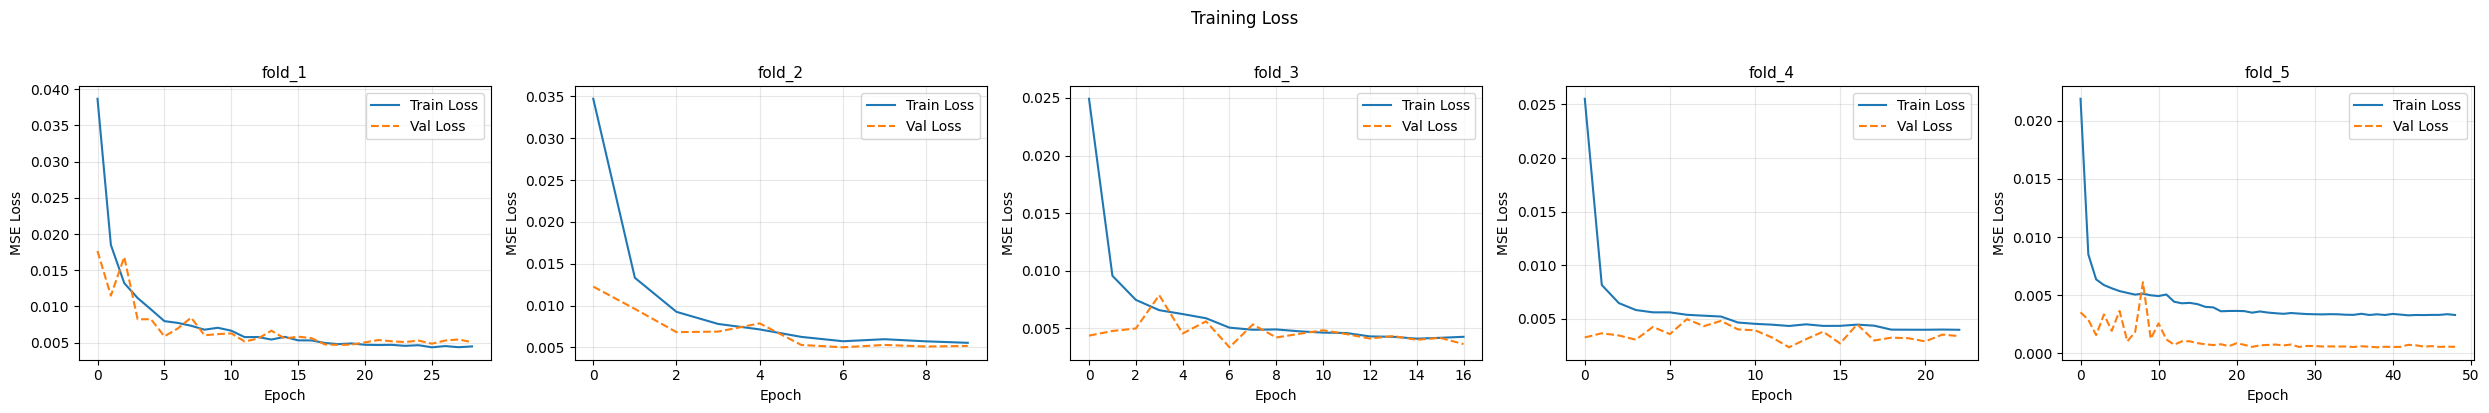

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf # Import tensorflow for model saving
import numpy as np # Import numpy if not already imported

# ─────────────────────────────────────────
# Save the last trained model
# ─────────────────────────────────────────
model_save_path = '/content/drive/MyDrive/patong_1dcnn_vl_24.h5'
try:
    last_model.save(model_save_path)
    print(f"✅ โมเดลถูกบันทึกที่: {model_save_path}")
except Exception as e:
    print(f"❌ เกิดข้อผิดพลาดในการบันทึกโมเดล: {e}")

# ─────────────────────────────────────────
# Regenerate and save the loss plot
# ─────────────────────────────────────────
# Re-using the plotting logic from the training cell
n_folds = len(fold_histories)
fig, axes = plt.subplots(1, n_folds, figsize=(5 * n_folds, 4))
if n_folds == 1:
    axes = [axes]

for ax, (fn, hist) in zip(axes, fold_histories.items()):
    ax.plot(hist.history['loss'],     label='Train Loss', linewidth=1.5)
    ax.plot(hist.history['val_loss'], label='Val Loss',   linewidth=1.5, linestyle='--')
    ax.set_title(fn, fontsize=11)
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'Training Loss', fontsize=12, y=1.02) # Removed 'Config: {config}'
plt.tight_layout()

plot_save_path = '/content/drive/MyDrive/loss_1dcnn_patong.png'
try:
    plt.savefig(plot_save_path, bbox_inches='tight', dpi=300)
    print(f"✅ กราฟ Loss ถูกบันทึกที่: {plot_save_path}")
except Exception as e:
    print(f"❌ เกิดข้อผิดพลาดในการบันทึกกราฟ: {e}")

plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assign y_test_seq to y_true and y_pred_test to y_pred
y_true = y_test_seq
y_pred = y_pred_test

# กำหนด threshold (ปรับตามข้อมูลจริง)
threshold = np.median(y_true)  # ใช้ค่ามัธยฐานของค่าจริงเป็น threshold

# แบ่งกลุ่มข้อมูลตาม threshold
high_idx = y_true >= threshold  # คลื่นสูง: ค่าจริงสูงกว่าหรือเท่ากับค่ามัธยฐาน
low_idx = y_true < threshold    # คลื่นต่ำ: ค่าจริงต่ำกว่าค่ามัธยฐาน

# คำนวณ metrics แยกกันสำหรับแต่ละกลุ่ม
for label, idx in [('คลื่นสูง', high_idx), ('คลื่นต่ำ', low_idx)]:
    # ตรวจสอบให้แน่ใจว่ามีจุดข้อมูลใน subset ปัจจุบันก่อนคำนวณ metrics
    if np.any(idx):
        mae  = mean_absolute_error(y_true[idx], y_pred[idx])
        rmse = np.sqrt(mean_squared_error(y_true[idx], y_pred[idx]))
        # เพิ่ม epsilon เล็กน้อยให้กับ y_true เพื่อหลีกเลี่ยงการหารด้วยศูนย์ใน MAPE
        mape = np.mean(np.abs((y_true[idx]-y_pred[idx]) / (y_true[idx] + 1e-10))) * 100
        r2   = r2_score(y_true[idx], y_pred[idx])
        print(f"{label}: MAE={mae:.4f}, RMSE={rmse:.4f}, MAPE={mape:.2f}, R²={r2:.4f}")
    else:
        print(f"{label}: No data points in this category.")

คลื่นสูง: MAE=0.0241, RMSE=0.0306, MAPE=3.26, R²=0.9585
คลื่นต่ำ: MAE=0.0212, RMSE=0.0275, MAPE=5.09, R²=0.7331



🎯 FINAL TEST RESULTS (Jan-Feb 2026)
  RMSE  : 0.0953
  MAE   : 0.0614
  NRMSE : 0.0792
  MAPE  : 15.34%


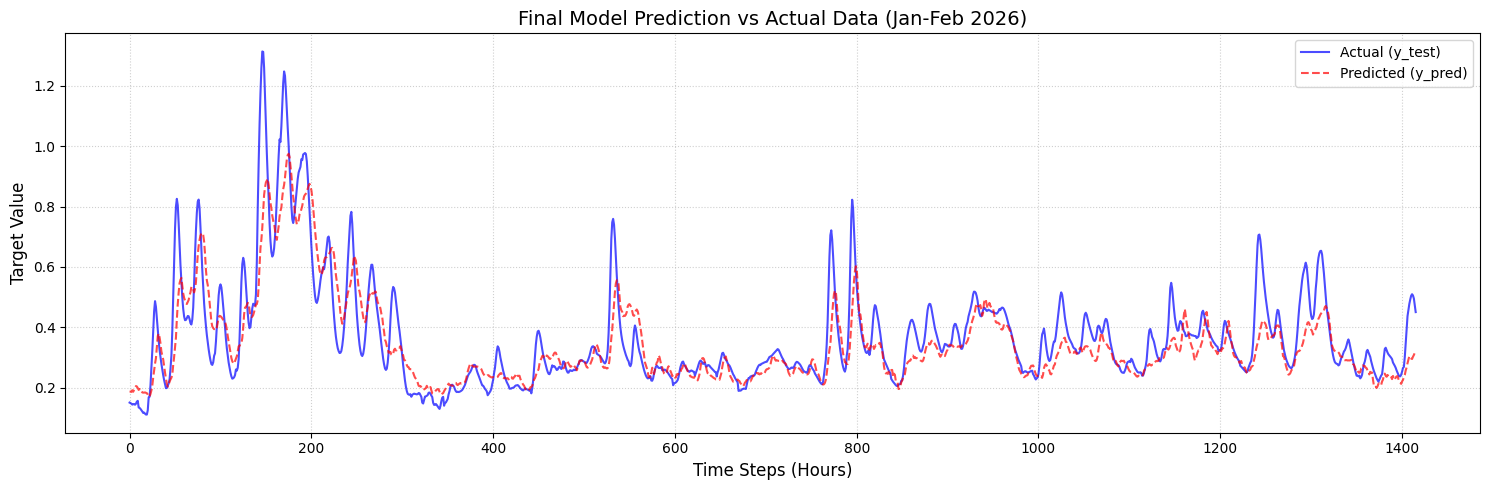

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. คำนวณ Metrics ประเมินความแม่นยำ (Unseen Data)
# ============================================================
test_rmse  = np.sqrt(mean_squared_error(y_test_seq, y_pred_test))
test_mae   = mean_absolute_error(y_test_seq, y_pred_test)

range_y_test = y_test_seq.max() - y_test_seq.min()
test_nrmse = test_rmse / range_y_test if range_y_test != 0 else np.nan

test_mape  = np.mean(np.abs((y_test_seq - y_pred_test) / (y_test_seq + 1e-10))) * 100

print("\n" + "="*50)
print("🎯 FINAL TEST RESULTS (Jan-Feb 2026)")
print("="*50)
print(f"  RMSE  : {test_rmse:.4f}")
print(f"  MAE   : {test_mae:.4f}")
print(f"  NRMSE : {test_nrmse:.4f}")
print(f"  MAPE  : {test_mape:.2f}%")
print("="*50)

# ============================================================
# 2. พล็อตกราฟเปรียบเทียบ (ค่าจริง vs ค่าพยากรณ์)
# ============================================================
plt.figure(figsize=(15, 5))
plt.plot(y_test_seq, label='Actual (y_test)', color='blue', alpha=0.7)
plt.plot(y_pred_test, label='Predicted (y_pred)', color='red', alpha=0.7, linestyle='--') # Changed y_pred to y_pred_test
plt.title('Final Model Prediction vs Actual Data (Jan-Feb 2026)', fontsize=14)
plt.xlabel('Time Steps (Hours)', fontsize=12)
plt.ylabel('Target Value', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Save the plot with the specified name
plot_save_path = '/content/drive/MyDrive/chaam 1d-cnn final.png'
try:
    plt.savefig(plot_save_path, bbox_inches='tight', dpi=300)
    print(f"✅ กราฟพยากรณ์ถูกบันทึกที่: {plot_save_path}")
except Exception as e:
    print(f"❌ เกิดข้อผิดพลาดในการบันทึกกราฟ: {e}")

✅ กราฟพยากรณ์ถูกบันทึกที่: /content/drive/MyDrive/chaam 1d-cnn final.png


<Figure size 640x480 with 0 Axes>